## RC and RL Networks Response

In [1]:
# Course utilities (do not modify this cell)
# Generated by post-canvas-notebooks. Edits above the marker are overwritten.
from pathlib import Path
import sys


def _find_courseutils():
    """Find courseutils no matter where the course repo was cloned."""
    here = Path.cwd().resolve()

    for parent in [here] + list(here.parents):
        for candidate in (parent / "courseutils",
                          parent / "Signals_and_Systems" / "courseutils"):
            if (candidate / "basic_material.py").is_file():
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the 'courseutils' folder. Clone "
        "https://github.com/mit-acl/Signals_and_Systems and run this "
        "notebook from inside the cloned repository, then restart the kernel."
    )


COURSEUTILS_DIR = _find_courseutils()

# courseutils is used both as a folder of modules and as a package,
# since control_materials does "import courseutils.basic_material",
# so the folder and its parent both go on the path.
for _location in (COURSEUTILS_DIR.parent, COURSEUTILS_DIR):
    if str(_location) not in sys.path:
        sys.path.insert(0, str(_location))

for _folder in ("data", "figs"):
    Path(_folder).mkdir(exist_ok=True)

# --- end course setup ---

import csv

import basic_material as bm
bm.setup_environment()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sympy.abc import t, x
from sympy.interactive import init_printing
init_printing(pretty_print=True)

from lcapy import Circuit, j, omega, s, exp
from lcapy import R, C, L, symbol

from IPython.display import display, Javascript
display(Javascript('document.title = "RC and RL Networks Response";'))

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<IPython.core.display.Javascript object>

# RC Network Example 1

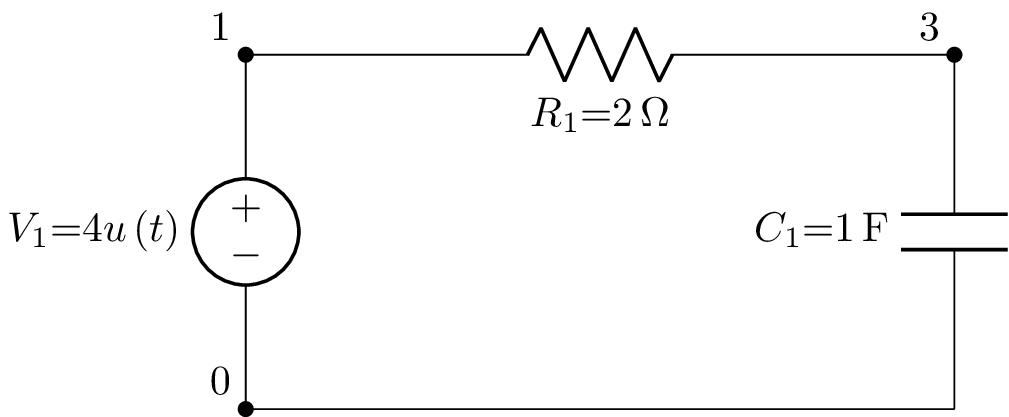

In [3]:
cct1 = Circuit("""
V1 1 0 {4*u(t)}; down=1.5
R1 1 3 2; right=3
C1 3 0_3 1 2; down=1.5
W4 0 0_3; right=3
""")
cct1.draw()

In [4]:
t = np.linspace(0, 10, 1000)
vc1 = cct1.C1.v.evaluate(t)
ic1 = cct1.C1.i.evaluate(t)
vr1 = cct1.R1.v.evaluate(t)

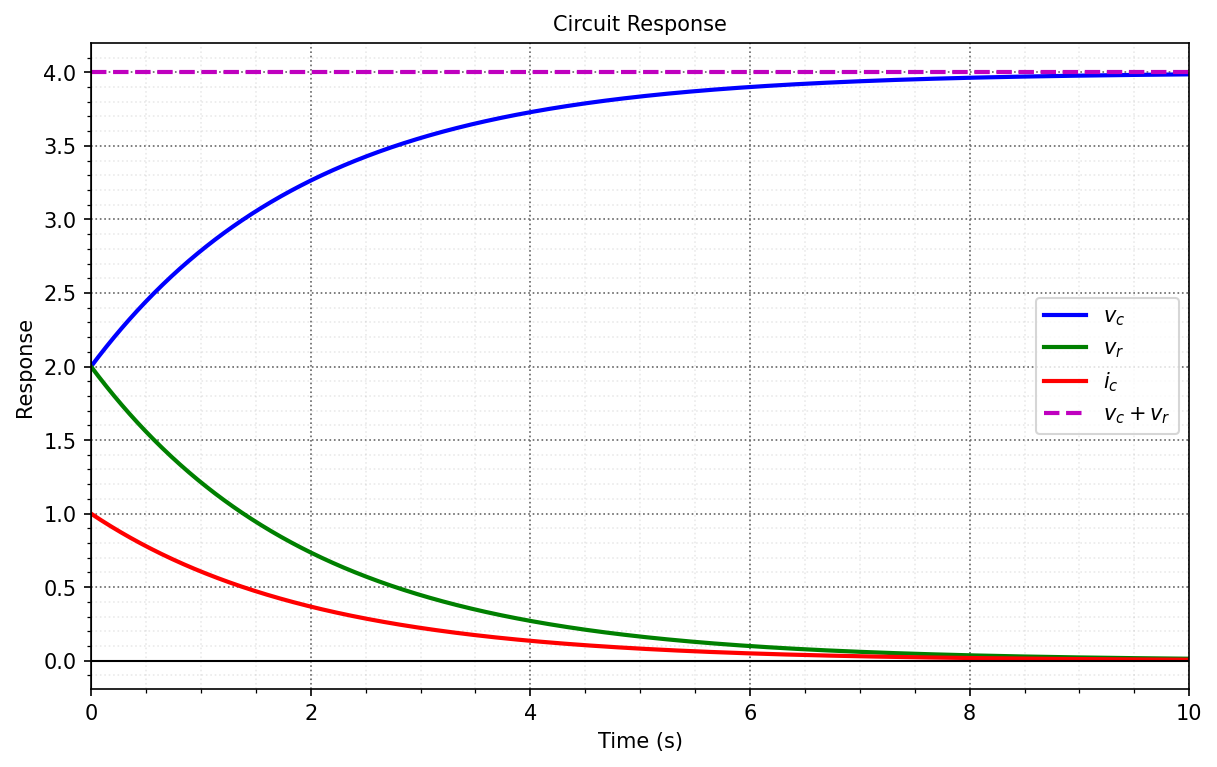

In [5]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vc1, linewidth=2, color='blue', label='$v_c$')
ax.plot(t, vr1, linewidth=2, color='green', label='$v_r$')
ax.plot(t, ic1, linewidth=2, color='red', label='$i_c$')
ax.plot(t, vc1+vr1, 'm--', label='$v_c+v_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
bm.nicegrid(ax)
plt.legend()
plt.savefig('figs/circuit-VRC1.png')
plt.show()

In [6]:
cct1.C1.v

       -t            
       ───           
        2            
4 - 2⋅ℯ     for t ≥ 0

# RC Network Example 2

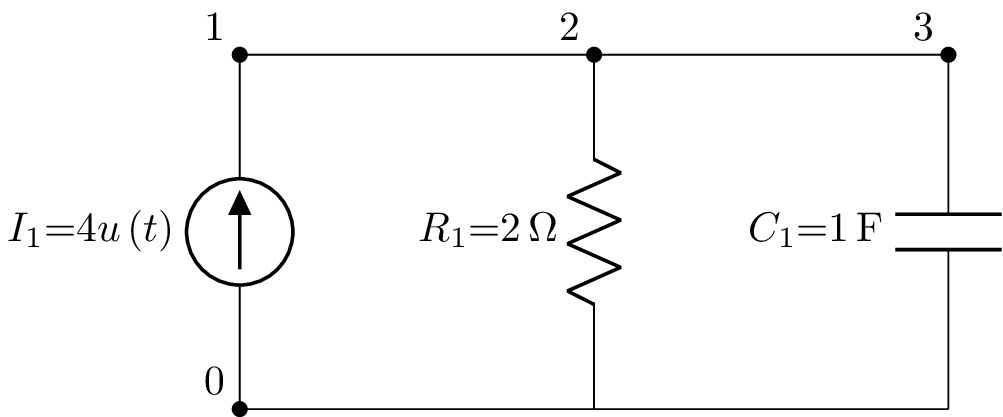

In [7]:
cct2 = Circuit("""
I1 1 0 {4*u(t)}; down=1.5
W1 1 2; right=1.5
R1 2 0_2 2; down=1.5
W2 2 3; right=1.5
C1 3 0_3 1 2; down=1.5
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")
cct2.draw()

In [8]:
t = np.linspace(0, 10, 1000)
vc2 = cct2.C1.v.evaluate(t)
ic2 = cct2.C1.i.evaluate(t)
ir2 = cct2.R1.i.evaluate(t)

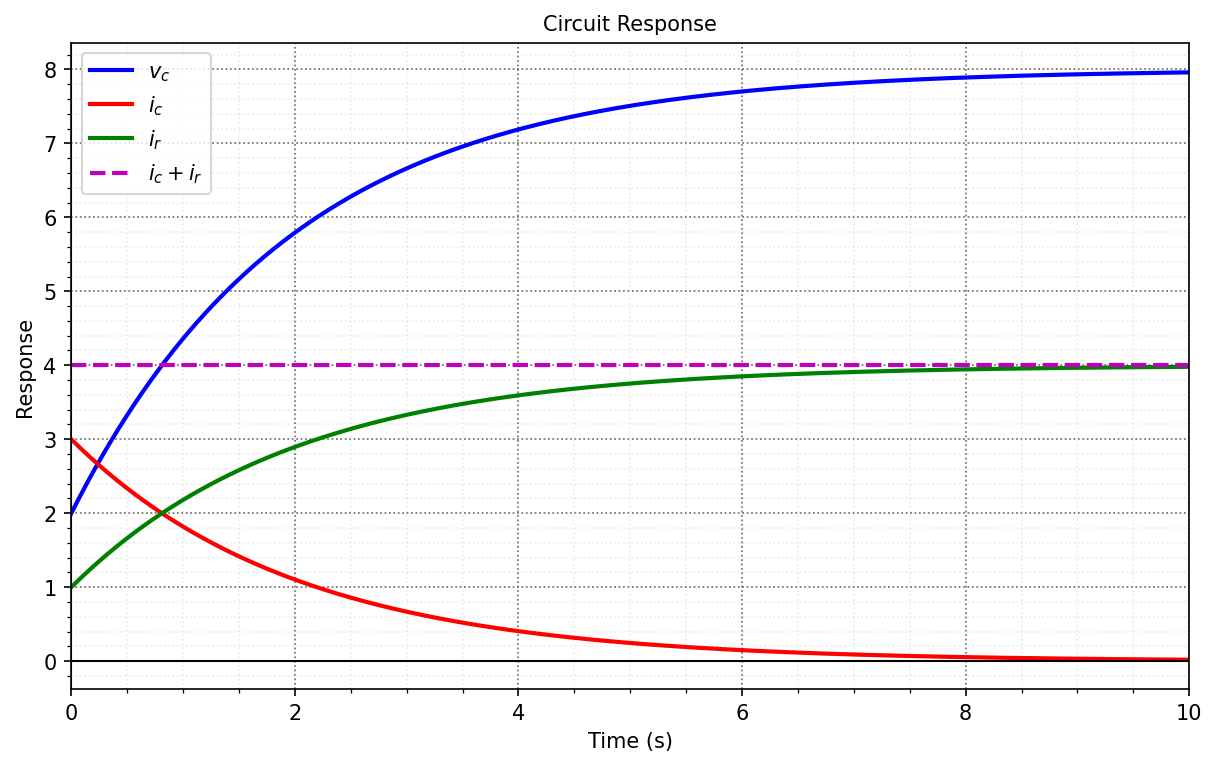

In [9]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vc2, linewidth=2, color='blue', label='$v_c$')
ax.plot(t, ic2, linewidth=2, color='red', label='$i_c$')
ax.plot(t, ir2, linewidth=2, color='green', label='$i_r$')
ax.plot(t, ic2+ir2, 'm--', label='$i_c+i_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
bm.nicegrid(ax)
plt.legend()
plt.savefig('figs/circuit-VRC2.png')
plt.show()

In [10]:
cct2.C1.v

       -t            
       ───           
        2            
8 - 6⋅ℯ     for t ≥ 0

# RL Network Example 3

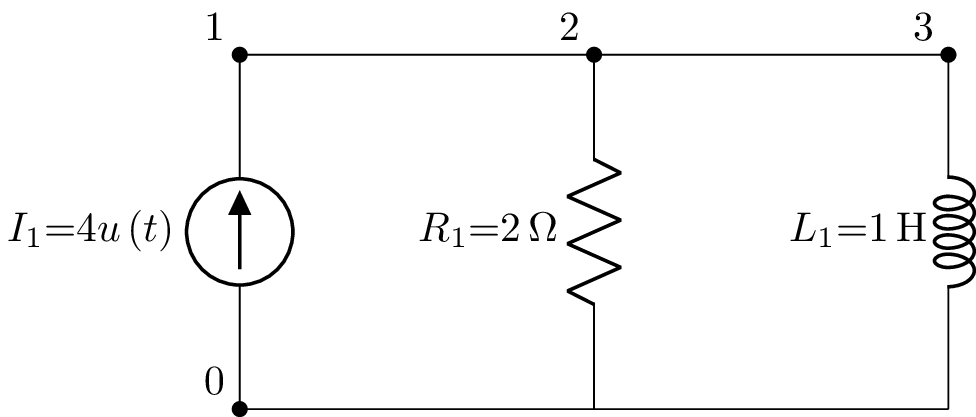

In [11]:
from lcapy import Circuit, s
cct3 = Circuit("""
I1 1 0 {4*u(t)}; down=1.5
W1 1 2; right=1.5
R1 2 0_2 2; down=1.5
W2 2 3; right=1.5
L1 3 0_3 1 2; down=1.5
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")
cct3.draw()

In [12]:
t = np.linspace(0, 4, 1000)
vl3 = cct3.L1.v.evaluate(t)
il3 = cct3.L1.i.evaluate(t)
ir3 = cct3.R1.i.evaluate(t)

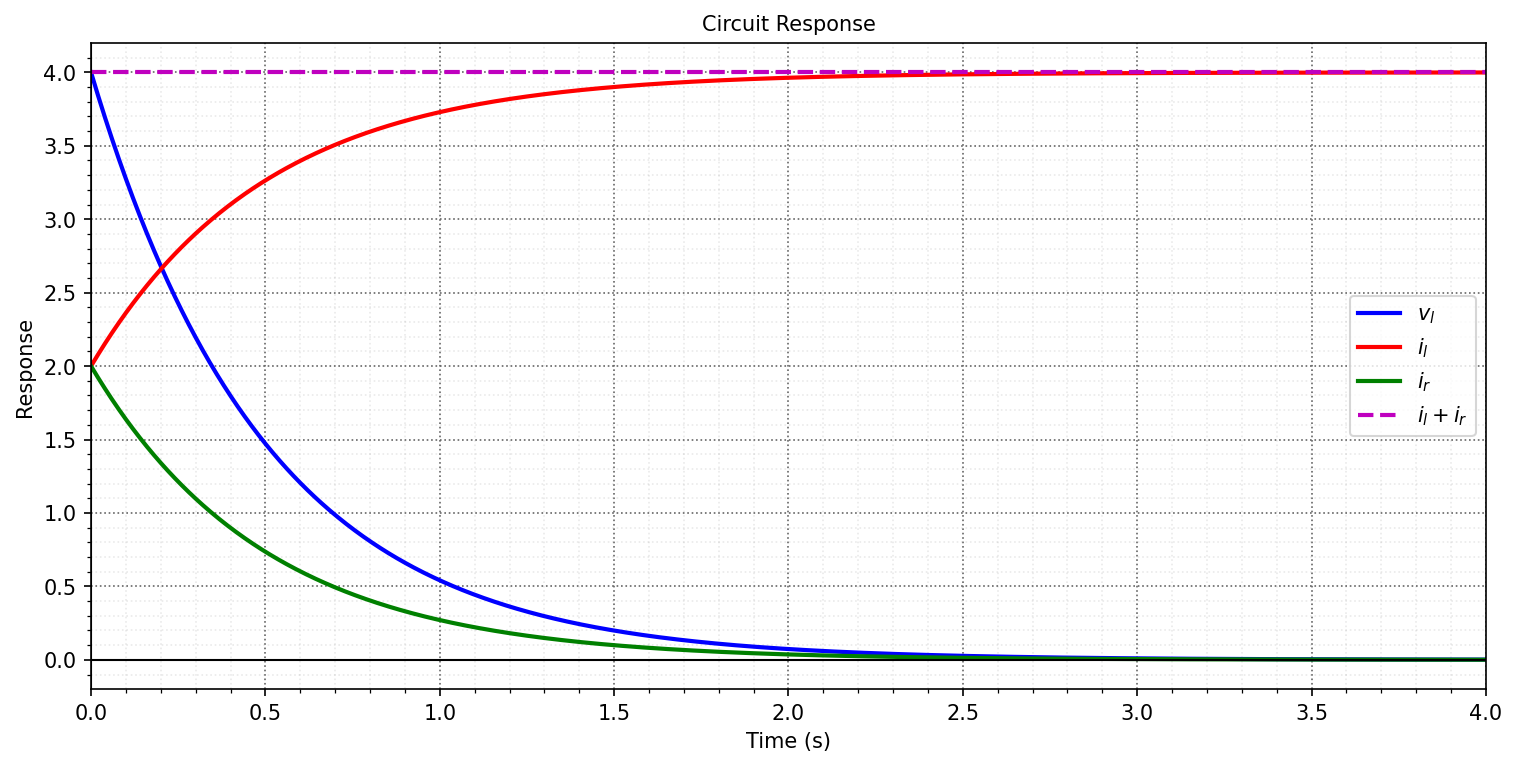

In [13]:
fig = plt.figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vl3, linewidth=2, color='blue', label='$v_l$')
ax.plot(t, il3, linewidth=2, color='red', label='$i_l$')
ax.plot(t, ir3, linewidth=2, color='green', label='$i_r$')
ax.plot(t, il3+ir3, 'm--', label='$i_l+i_r$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
bm.nicegrid(ax)
plt.legend()
plt.savefig('figs/circuit-VRC3.png')
plt.show()

In [14]:
cct3.L1.i

       -2⋅t           
4 - 2⋅ℯ      for t ≥ 0

# RC Network Example 4 (various step inputs)

In [15]:
CC = 150e-9
RR = 4.7e3
RC = CC * RR
tau = np.round(2*RC*10000)/10000

cct4 = Circuit(f"""
V1 1 0 {{(u(t)-2*u(t-{2*tau:.6e})+2*u(t-{4*tau:.6e})-2*u(t-{5*tau:.6e})+2*u(t-{7*tau:.6e}))}}; down=1.5
R1 1 3 {RR:.6e}; right=3
C1 3 0_3 {CC:.6e} 0; down=1.5
W4 0 0_3; right=3
""")

In [16]:
cct4.C1.v

⎛     -200000⋅t ⎞        ⎛       1120   200000⋅t⎞                 ⎛       1960 ↪
⎜     ──────────⎟        ⎜       ──── - ────────⎟                 ⎜       ──── ↪
⎜        141    ⎟        ⎜       141      141   ⎟                 ⎜       141  ↪
⎝1 - ℯ          ⎠⋅u(t) + ⎝2 - 2⋅ℯ               ⎠⋅u(t - 7/1250) + ⎝2 - 2⋅ℯ     ↪
                                                                               ↪

↪    200000⋅t⎞               ⎛   560   200000⋅t    ⎞                 ⎛   1400  ↪
↪  - ────────⎟               ⎜   ─── - ────────    ⎟                 ⎜   ────  ↪
↪      141   ⎟  ⎛     49 ⎞   ⎜   141     141       ⎟                 ⎜   141   ↪
↪            ⎠⋅u⎜t - ────⎟ + ⎝2⋅ℯ               - 2⎠⋅u(t - 7/2500) + ⎝2⋅ℯ      ↪
↪               ⎝    5000⎠                                                     ↪

↪   200000⋅t    ⎞              
↪ - ────────    ⎟              
↪     141       ⎟              
↪            - 2⎠⋅u(t - 7/1000)
↪                              

In [17]:
t4 = np.linspace(0,11*tau, 1000)
vc4 = cct4.C1.v.evaluate(t4)
ic4 = cct4.C1.i.evaluate(t4)
vr4 = cct4.R1.v.evaluate(t4)
v4 = cct4.V1.v.evaluate(t4)

print(f"Network value is {RC= :8.6f}")

Network value is RC= 0.000705


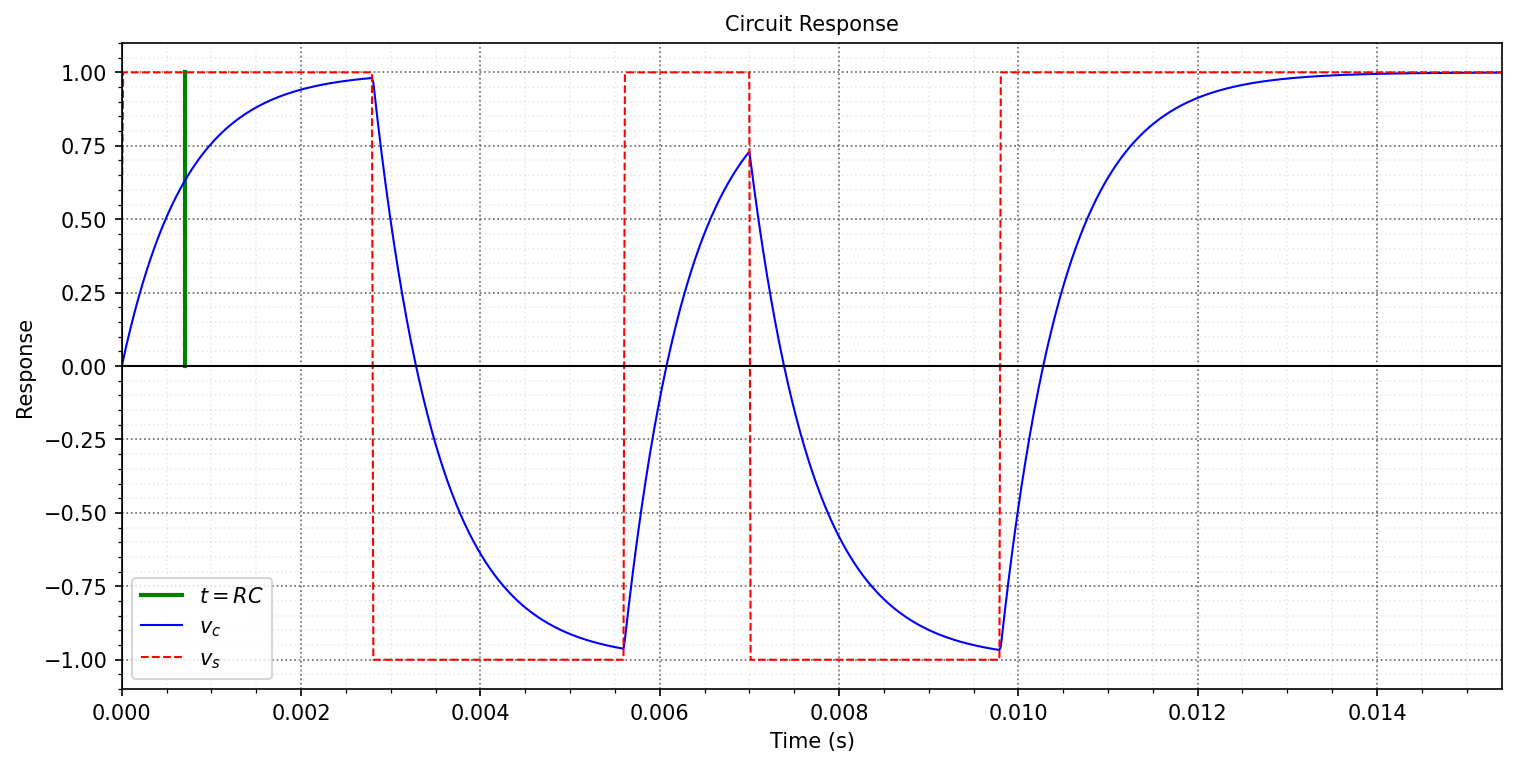

In [18]:
fig = plt.figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot([RC, RC], [0, 1], linewidth=2, color='green', label='$t=RC$')
ax.plot(t4, vc4, linewidth=1, color='blue', label='$v_c$')
ax.plot(t4, v4, 'r--', linewidth=1, label='$v_s$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
bm.nicegrid(ax)
plt.legend()
plt.savefig('figs/circuit-VRC1.png')
plt.show()

## RLC Circuit
* Initial voltage on capacitor 20V
* Step input of voltage source

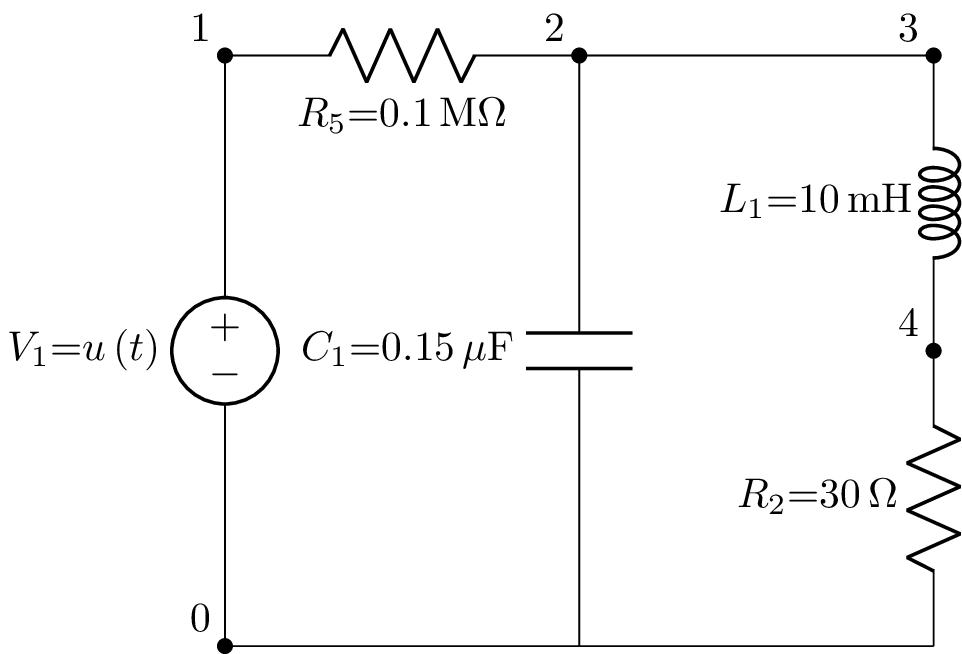

In [19]:
R5 = 1e5
R2 = 30
C = 1.5e-7
L = 0.01
Vs = 1
vc0 = 1
iL0 = vc0 / R2

cct5 = Circuit(f"""
V1 1 0 {{{Vs}*u(t)}}; down=2.5
R5 1 2 {R5}; right=1.5
C1 2 0_2 {C} {vc0}; down=2.5
W2 2 3; right=1.5
L1 3 4 {L} {iL0}; down=1.25
R2 4 0_3 {R2}; down=1.25
W3 0 0_2; right=1.5
W4 0_2 0_3; right=1.5
""")

cct5.draw()

In [20]:
a = 1/(R5*C) + R2/L
b = 1/(L*C) + R2/(L*R5*C)
rhs = R2*Vs/(L*R5*C)

v_inf = rhs / b
alpha = a/2
wd = np.sqrt(b - alpha**2)
vcdot0 = ((Vs - vc0)/R5 - iL0) / C
A = vc0 - v_inf
B = (vcdot0 + alpha*A) / wd

def vc_analytic(t):
    t = np.asarray(t)
    out = np.full_like(t, vc0, dtype=float)

    tp = t[t >= 0]
    out[t >= 0] = v_inf + np.exp(-alpha*tp) * (
        A*np.cos(wd*tp) + B*np.sin(wd*tp)
    )

    return out

def vcdot_analytic(t):
    scalar = np.isscalar(t)
    t = np.asarray(t, dtype=float)

    out = np.zeros_like(t, dtype=float)
    mask = t >= 0
    tp = t[mask]

    out[mask] = np.exp(-alpha*tp) * (
        (-alpha*A + wd*B)*np.cos(wd*tp)
        + (-alpha*B - wd*A)*np.sin(wd*tp)
    )

    return out.item() if scalar else out


def il_analytic(t):
    scalar = np.isscalar(t)
    t = np.asarray(t, dtype=float)

    out = np.full_like(t, iL0, dtype=float)
    mask = t >= 0
    tp = t[mask]

    vc = vc_analytic(tp)
    vcdot = vcdot_analytic(tp)

    out[mask] = (Vs - vc)/R5 - C*vcdot

    return out.item() if scalar else out

In [21]:
import sympy as sp
t_sym = sp.symbols('t', real=True)


t5 = np.linspace(-0.00005, 0.001, 1000)

def lcapy_to_numpy(expr):
    sexpr = expr.expr if hasattr(expr, "expr") else expr
    sexpr = sp.N(sexpr)
    return sp.lambdify(t_sym, sexpr, modules=["numpy"])

vc_fun = lcapy_to_numpy(cct5.C1.v)
vl_fun = lcapy_to_numpy(cct5.L1.v)
il_fun = lcapy_to_numpy(cct5.L1.i)
vr_fun = lcapy_to_numpy(cct5.R2.v)

vc5 = vc_fun(t5)
vl5 = vl_fun(t5)
il5 = il_fun(t5)
vr5 = vr_fun(t5)

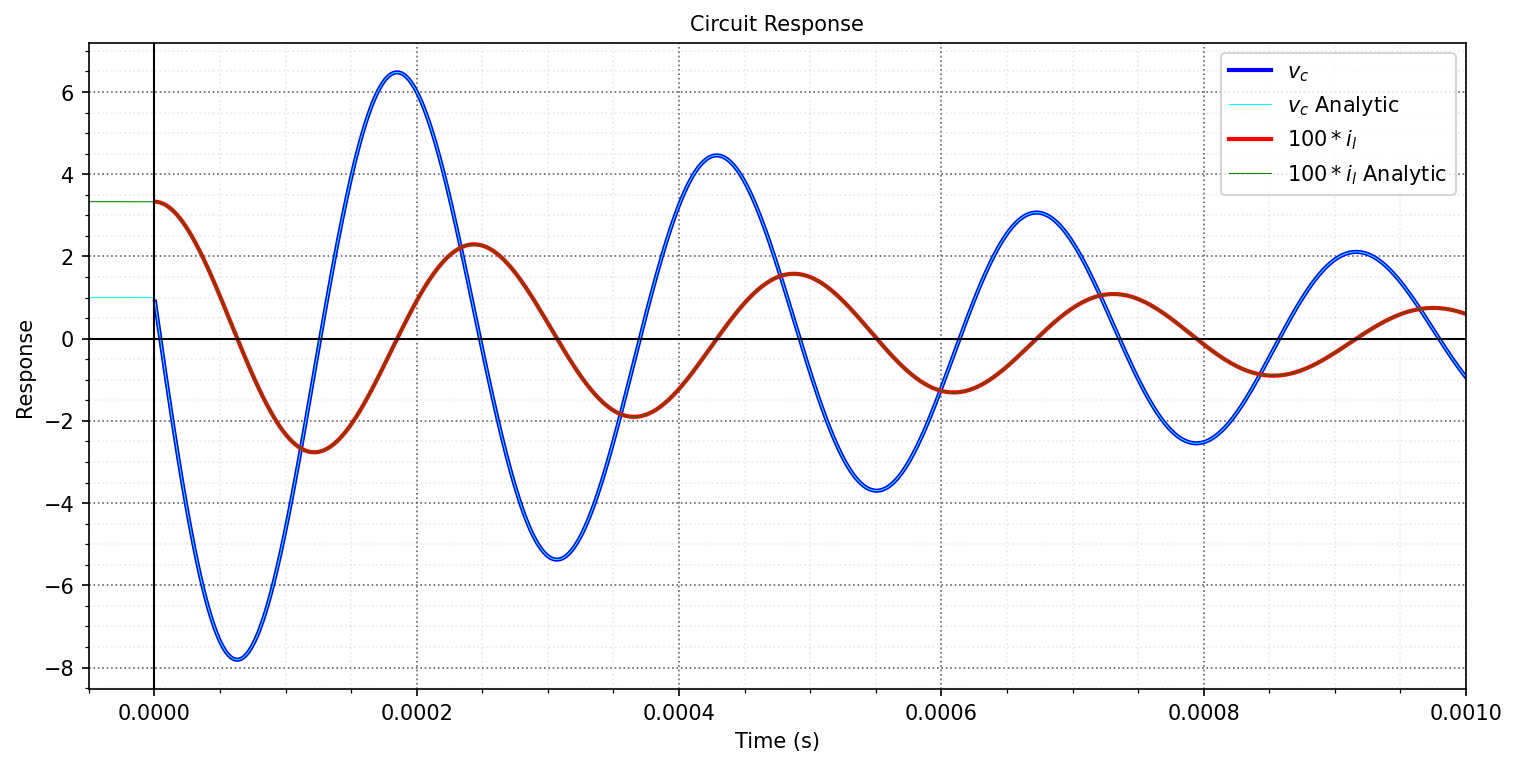

In [22]:
fig = plt.figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t5, vc5, linewidth=2, color='blue', label='$v_c$')
ax.plot(t5, vc_analytic(t5), linewidth=.5, color='cyan', label='$v_c$ Analytic')
ax.plot(t5, 100*il5, linewidth=2, color='red', label='$100*i_l$')
ax.plot(t5, 100*il_analytic(t5), linewidth=.5, color='green', label='$100*i_l$ Analytic')
il_analytic(0.0)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
#ax.set_ylim([-.1,.1])
bm.nicegrid(ax)
plt.legend()
#savefig('figs/circuit-VRC1.png')
plt.show()